<a href="https://colab.research.google.com/github/AhalaAyyalas/MachineLearning/blob/main/ML_Assign17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PART 1

1) In the sentence "The dog chased the ball because it was bouncy," what does "it" refer to? Explain how the attention mechanism helps a Transformer figure this out. Which word would receive the highest attention score from "it"?

-- "it" refers to the ball. The attention mechanism lets "it" look back at all words in the sentence and assign scores; "ball" gets the highest attention score because it's the most relevant noun in that context.

2) Explain the difference between how an RNN (older model) and a Transformer process a sentence. Why is the Transformer's approach faster and better at understanding long sentences?

-- RNN reads words in left to right order and it tends to 'forget' words it read earlier in long sentences. A transformer looks at all words in parallel making it more efficient and and better at understanding


3) Name the three types of Transformer models (encoder-only, encoder-decoder, decoder-only). For each type, give one real-world product or model that uses it and explain what task it performs.

-- Encoder only: BERT
   Decoder only: ChatGPT
   Encoder-Decoder: Google Translate

# PART 2

1) Type in the sentence "I love machine learning!" and record how many tokens it produces. Then type in "Supercalifragilisticexpialidocious" and record how many tokens it produces. Take a screenshot of each. Why does the long word produce more tokens?

**I love machine learning!**

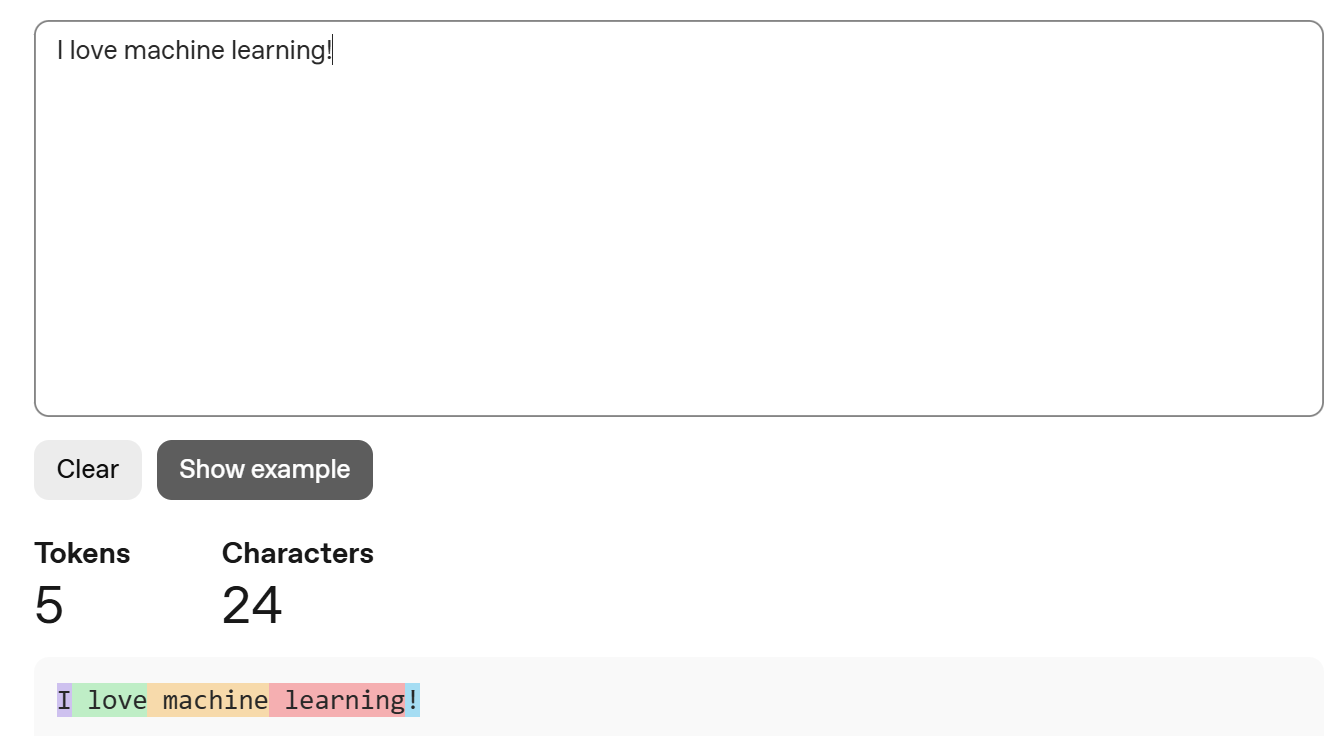

**Supercalifragilisticexpialidocious**

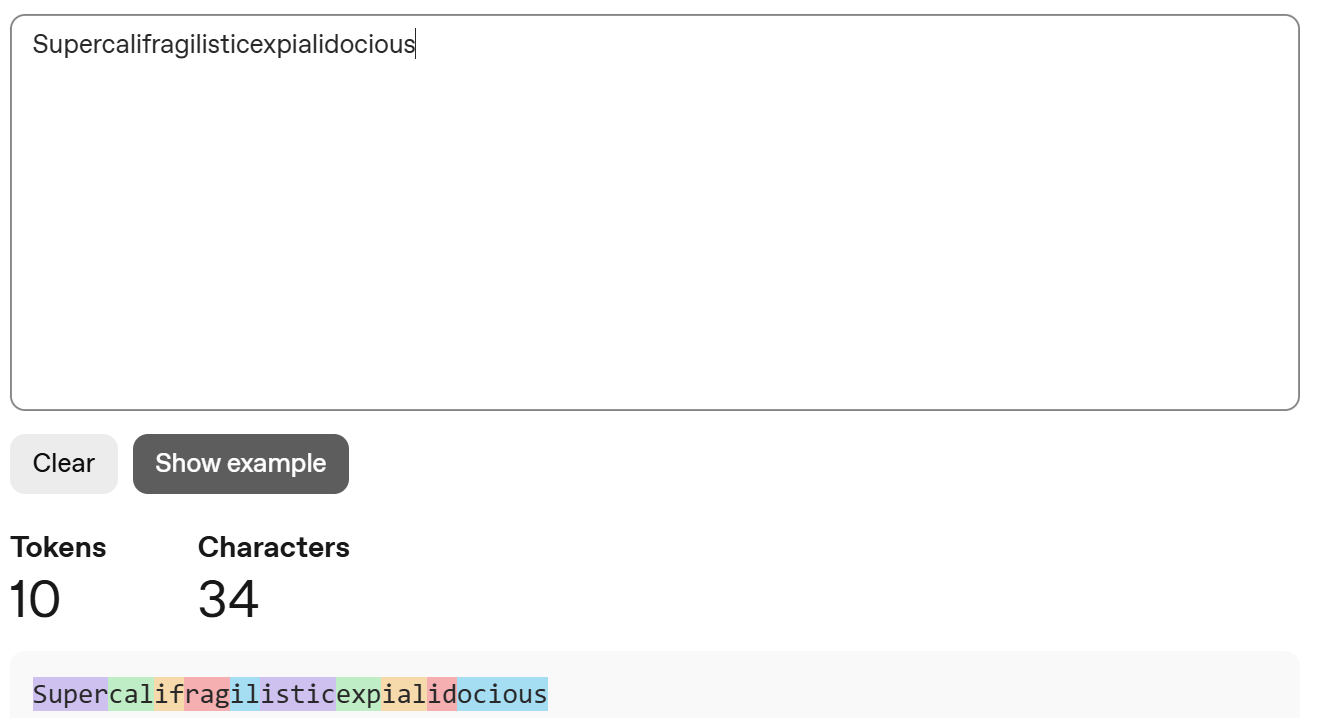


Longer words take more number of tokens as they are built of multiple subparts and are less frequently used as whole words in traning data.

2) Type in your full name and record the tokens. Then type in a common English sentence of at least 10 words. Calculate the ratio of tokens to words for both. Is it always 1 token per word? Why or why not?

-- Ahala Ayyalasomayajula: 10 tokens, 22 characters
The cat sat on the mat wearing a bat hat.: 11 tokens, 41 characters

It is not always 1 token per 1 word as rare or long words freqeuntly take up more than one token. Short and words that are used together often may take up one word together.

3) (2 pts) Type in "123 + 456 = 579" and look at how the numbers are tokenized. Now type "How many R's are in strawberry?" and look at how "strawberry" is tokenized. Based on what you see, explain in 2–3 sentences why LLMs sometimes struggle with math and spelling.

-- 123 + 456 = 579: 7 tokens, 15 characters
How many R's are in strawberry?: 8 tokens, 31 characters

LLMs dont actually calculate they just go ahead with the predictions they make. So, any simple equation maybe easy to solve but complex ones get tricky. They also look at words as tokens, not letters. So they dont actually see individual characters making it tricky to calculate the number of 'a's in word (for example).

# PART 3

In [2]:
#@title Installing Hugging face

!pip install transformers -q
print("Transformers library installed successfully!")

import transformers
print(f"Version: {transformers.__version__}")


Transformers library installed successfully!
Version: 5.0.0


In [5]:
#@title Sentiment Analysis

from transformers import pipeline

# Load a pretrained sentiment analysis model
# (This downloads the model the first time — may take a minute)
print("Loading pretrained sentiment model...")
classifier = pipeline("sentiment-analysis")
print("Model loaded!\n")

# Test with sample reviews
reviews = [
    "This movie was absolutely incredible! A true masterpiece.",
    "Worst film I've ever seen. Complete waste of time and money.",
    "It was okay. Some good moments but overall pretty average.",
    "The acting was phenomenal and the storyline kept me on the edge of my seat!",
    "Boring, predictable, and way too long. I almost fell asleep.",
]

print("Sentiment Analysis Results:")
print("=" * 65)
for review in reviews:
    result = classifier(review)[0]
    emoji = "👍" if result['label'] == 'POSITIVE' else "👎"
    print(f'{emoji} {result["label"]} ({result["score"]:.1%}): "{review[:55]}..."')
print("=" * 65)

# TESTING

my_sentences = [
    "I really love a good, warm, home-cooked meal.",
    "Exams are the most useless thing ever invented by mankind.",
    "The taxi arrived late but the driver helped us reach safely.",
]

print("Your sentences:")
print("-" * 50)
for sentence in my_sentences:
    result = classifier(sentence)[0]
    emoji = "👍" if result['label'] == 'POSITIVE' else "👎"
    print(f'{emoji} {result["label"]} ({result["score"]:.1%})')
    print(f'   "{sentence}"')
    print()

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading pretrained sentiment model...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Model loaded!

Sentiment Analysis Results:
👍 POSITIVE (100.0%): "This movie was absolutely incredible! A true masterpiec..."
👎 NEGATIVE (100.0%): "Worst film I've ever seen. Complete waste of time and m..."
👍 POSITIVE (99.7%): "It was okay. Some good moments but overall pretty avera..."
👍 POSITIVE (100.0%): "The acting was phenomenal and the storyline kept me on ..."
👎 NEGATIVE (100.0%): "Boring, predictable, and way too long. I almost fell as..."
Your sentences:
--------------------------------------------------
👍 POSITIVE (100.0%)
   "I really love a good, warm, home-cooked meal."

👎 NEGATIVE (100.0%)
   "Exams are the most useless thing ever invented by mankind."

👍 POSITIVE (99.8%)
   "The taxi arrived late but the driver helped us reach safely."



In [7]:
#@title Text Generation

from transformers import pipeline

print("Loading GPT-2 text generation model...")
generator = pipeline("text-generation", model="gpt2")
print("Model loaded!\n")

# Try different prompts!
prompt = "The future of artificial intelligence is"

print(f'Prompt: "{prompt}"')
print("=" * 60)

outputs = generator(
    prompt,
    max_length=60,           # Maximum total length (prompt + generated)
    num_return_sequences=3,  # Generate 3 different completions
    do_sample=True,          # Enable randomness for variety
    temperature=0.8,         # Controls randomness (lower = more predictable)
)

for i, output in enumerate(outputs):
    print(f"\nGeneration {i+1}:")
    print(f"  {output['generated_text']}")

print("\n" + "=" * 60)
print("Notice: Each generation is different because the model samples")
print("from probabilities — this is the 'temperature' parameter at work!")

# TESTING

my_prompts = [
    "Long ago, in a faraway kingdom",
    "The worst way to lie to someone is",
]

for prompt in my_prompts:
    output = generator(prompt, max_length=50, num_return_sequences=1, do_sample=True, temperature=0.7)
    print(f'Prompt: "{prompt}"')
    print(f'  -> {output[0]["generated_text"]}')
    print()

Loading GPT-2 text generation model...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=60) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Model loaded!

Prompt: "The future of artificial intelligence is"


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Generation 1:
  The future of artificial intelligence is bright!

We've been using machine learning algorithms to make our games smarter and more accurate, our games are designed to be played by AI. This gives us a great opportunity to test and refine the performance of our games, to use these algorithms on our own software as well as on others' with the help of other developers.

So what are we waiting for?

To continue developing our game we need to find new means, to learn more about what we are trying to achieve, and to share these experiences with other game developers.

We are also trying to figure out how we can use AI to get our games into the hands of more experienced game developers, and how to build something that works on Steam, such as in-game tools, or on your own game, without requiring your team members to share the same knowledge and experience.

There are two main sources of knowledge available right now: the game developer's and the game's own knowledge.

There are 

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Prompt: "Long ago, in a faraway kingdom"
  -> Long ago, in a faraway kingdom, the Great Dragon King, the Jotun of the Dragon, had become a powerful and powerful warrior, which was, according to legend, the power of the Dragon Lord.

He had also attained the rank of the Dragon Lord, and his magic had become so powerful that this dragon had become the Dragon Lord's apprentice. Since then, Jotun had become the Dragon Lord's master and heir.

The Jotun's master had become the Dragon Lord's heir, and since then, the Dragon Lord had become the Dragon Lord's own son.

However, as long as he was the Dragon Lord's heir, the Dragon Lord did not care who became the Dragon Lord's master. If the Dragon Lord was the Dragon Lord's own son, then the Dragon Lord's rule would not be the same.

He had become the Dragon Lord's heir, and as long as he was the Dragon Lord's own son, the Dragon Lord did not care who became the Dragon Lord's master.

And then, the Dragon Lord's father died.

The dragon lord h

In [10]:
#@title Question Answering

from transformers import pipeline

print("Loading question-answering model...")
qa = pipeline("question-answering")
print("Model loaded!\n")

context = """
Sachin Tendulkar, widely regarded as the greatest batsman in cricket history, was born on
April 24, 1973, in Mumbai, India. He made his international debut at just 16 years old in 1989
against Pakistan and went on to play 664 international matches across Tests and ODIs over
a career spanning 24 years. He is the only player to have scored 100 international centuries,
amassing over 34,000 runs across all formats — records that remain unmatched to this day.
Known for his flawless technique, incredible consistency, and calm temperament under
pressure, Tendulkar was the backbone of Indian batting for over two decades. He retired in
November 2013, leaving behind a legacy that transcends cricket, earning him the Bharat
Ratna, India's highest civilian honor, making him the first sportsperson to receive it.
"""

questions = [
    "Which country did Sachin Tendulkar make his debut against?",
    "What unique batting record does Tendulkar hold?",
    "How many total runs did Tendulkar score across all international formats?",
    "What distinction did Tendulkar earn upon receiving the Bharat Ratna?",
]

print("Context paragraph loaded. Asking questions...\n")
for q in questions:
    result = qa(question=q, context=context)
    print(f'Q: {q}')
    print(f'A: "{result["answer"]}" (confidence: {result["score"]:.1%})')
    print()

No model was supplied, defaulted to distilbert/distilbert-base-cased-distilled-squad and revision 564e9b5.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading question-answering model...


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

Model loaded!

Context paragraph loaded. Asking questions...

Q: Which country did Sachin Tendulkar make his debut against?
A: "Pakistan" (confidence: 99.4%)

Q: What unique batting record does Tendulkar hold?
A: "over 34,000 runs" (confidence: 6.8%)

Q: How many total runs did Tendulkar score across all international formats?
A: "34,000" (confidence: 80.1%)

Q: What distinction did Tendulkar earn upon receiving the Bharat Ratna?
A: "highest civilian honor" (confidence: 49.1%)



# PART 4

1) Think about the entire course journey from Week 1 to Week 26. Pick one concept from an earlier week (e.g., train/test split, overfitting, feature extraction, accuracy, classification) and explain how that same concept shows up in Transformers and LLMs.

-- Overfitting is when a model learns the training data too well and does not function properly when introduced to a new dataset. This also takes place in LLMs as they can literally memorise vast data portions and when they come across a prompt that seems familiar, they spit out the same information.

2) ChatGPT and Claude sometimes "hallucinate" — they confidently say things that are wrong. Based on what you learned about how these models generate text (next-token prediction), explain in 3–4 sentences why hallucination happens.

-- Various AI models like ChatGPT predict the next word or token and dont think in paragraphs. There is a built in randomness function called 'temperature' ensuring that the responses are creative. Since the model always picks the most plausible next word, theyre are chances of it hallucinating and lying confidently.

3) If you could build an AI application using Transformers, what would it be? Describe the application in 3–4 sentences. What type of Transformer would you use (encoder-only, encoder-decoder, or decoder-only) and why?

-- A recipe suggestor: You punch in whatever ingredients you have at home, and it tells you what food items you can make. It handles spelling mistakes and interrelations between ingredients. This is an encoder-only transformer as it only understands and matches, doesnt generate anything entitely new.